In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os 

# Explicacion

Este caso se intentó hacer antes de evaluar los contenidos de la clase 5. La logica que se buscó fue:

1. Reescalar la imagen del logo para que siempre sea mas pequeña que la imagen a detectar
2. Utilizar canny, para quitar influencia de colores, fondos, etc, del logo
3. De forma iterativa, ir intentando detectar elementos en la imagen, hasta que la imagen a detectar sea del tamaño del logo

Esto unicamente nos funcionó en un caso, pero lo dejamos como muestra de la logica que intentamos aplicar

In [2]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

In [3]:
def detection_function(img_path:str, template_path:str, resize_percentaje, threshold):
    # Procesamos template

    template_img = cv.imread(template_path,0)
    template_edges = cv.Canny(template_img,100,200)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_img, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(template_edges)
    plt.show()

    img_grayscale = cv.imread(img_path,0)
    image_edges = cv.Canny(img_grayscale,100,200)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_grayscale, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(image_edges)
    plt.show()

    max_dim = np.argmax(template_edges.shape)

    scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

    # Resize the image (scaling down)
    resized_down_template = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_edges, cmap='gray')
    plt.title("Template original")
    plt.subplot(1,2,2)
    plt.imshow(resized_down_template, cmap= 'gray')
    plt.title("Template reescalado")
    plt.show()
 
    current_image = image_edges.copy()

    edges = resized_down_template.copy()

    while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

        img_show = current_image.copy()

        method = eval('cv.TM_CCOEFF_NORMED')


        #current_edges = cv.Canny(current_image,100,200)

        res = cv.matchTemplate(current_image, edges, method)

        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

        w, h = edges.shape[::-1]

        threshold = 0.4

        loc = np.where( res >= threshold)
        for pt in zip(*loc[::-1]):
            cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (255,255,255), 2)

        if np.max(res) > threshold:
            print(f"Valor de confianza de deteccion: {np.max(res)}")

        # Graficamos el procesamiento y la salida
        #----------------------------------------
        plt.figure(figsize=(15, 5))
        # Resultado de coincidencia
        plt.subplot(121),plt.imshow(res,cmap = 'gray')
        plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

        # Imagen original con recuadros
        plt.subplot(122),plt.imshow(img_show, cmap='gray')
        plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
        #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        plt.suptitle(method)
        plt.show()
        
        print(current_image.shape)
        current_image = cv.resize(current_image, None, fx=0.80, fy=0.80, interpolation=cv.INTER_AREA).copy()
        #cv.imshow('Downscaled', current_image)
        #cv.waitKey(500)


In [4]:
resize_percentaje = 40

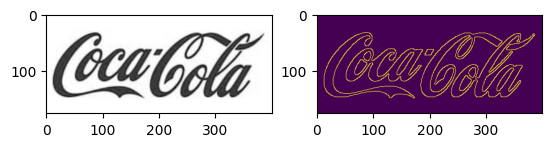

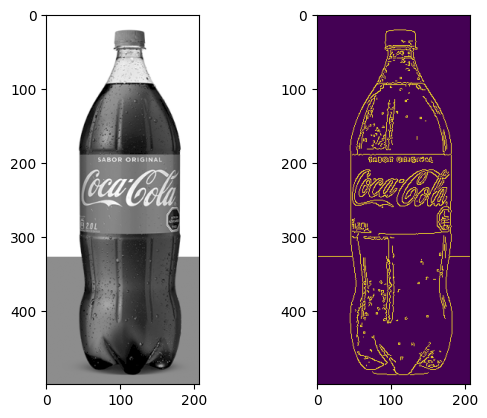

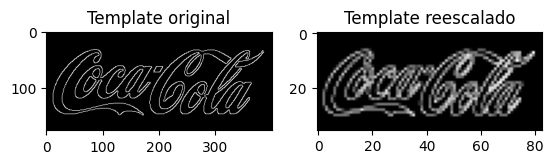

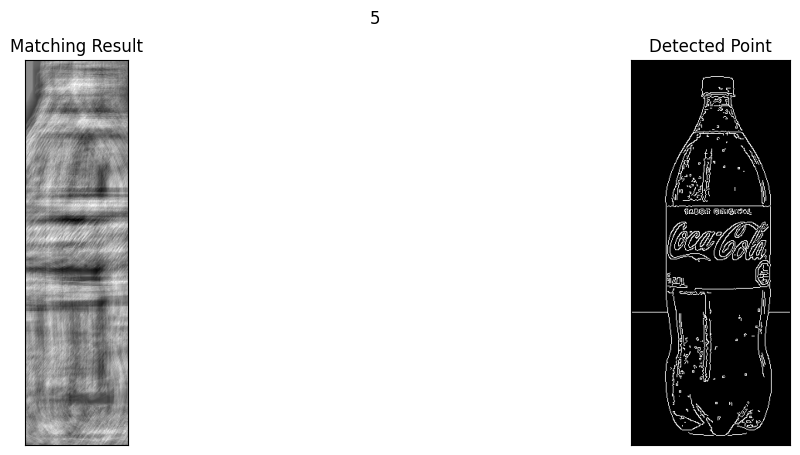

(500, 207)


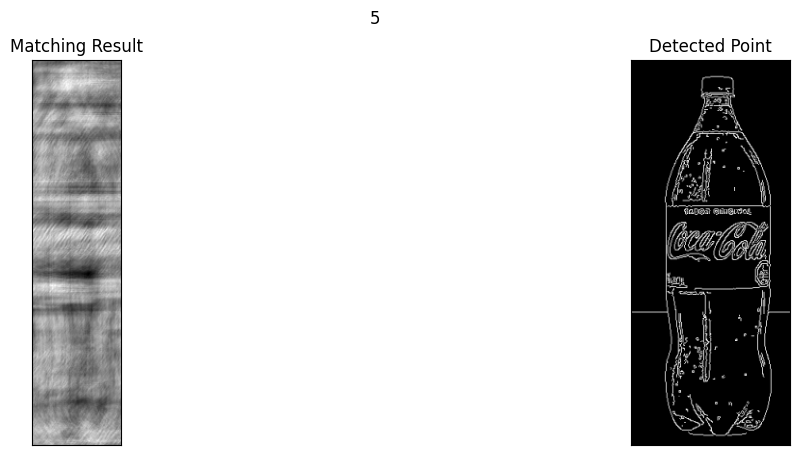

(400, 166)


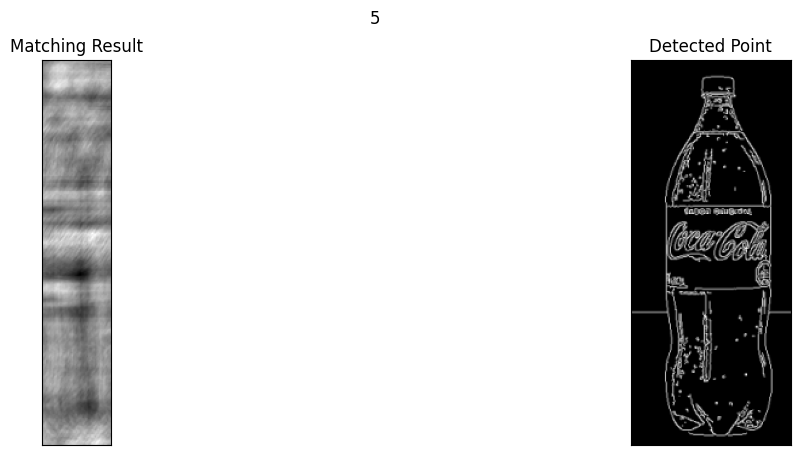

(320, 133)
Valor de confianza de deteccion: 0.510247528553009


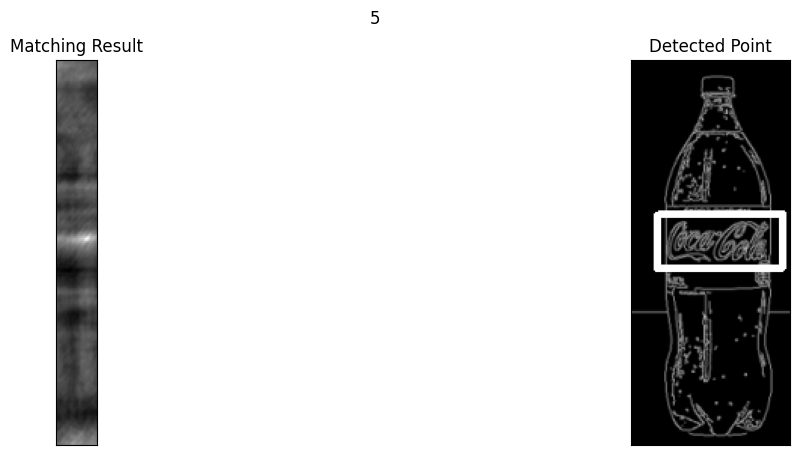

(256, 106)


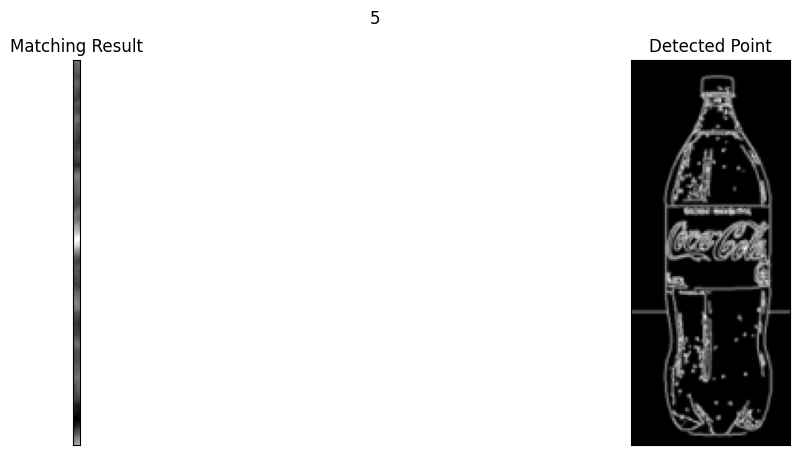

(205, 85)


In [5]:
detection_function(img_path=img_path, template_path=template_path, resize_percentaje=40, threshold=0.4)

Esto parece indicar resultados correctos, pero existe un problema. Si analizamos el valor de confianza encontramos que este es del 51%, no es muy alto. Si lo verificamos para otra imagen, tenemos:

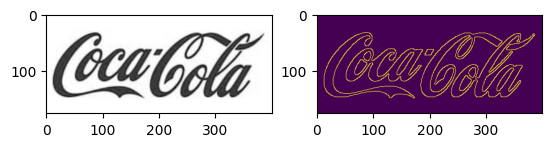

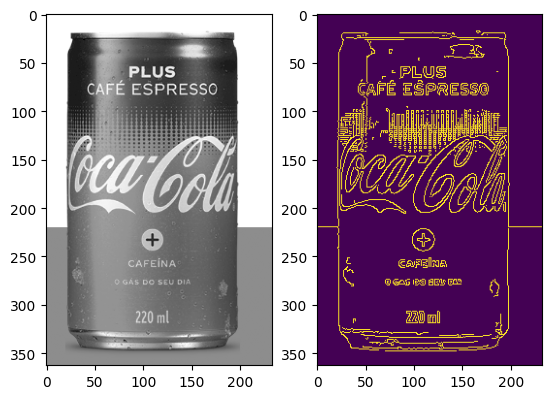

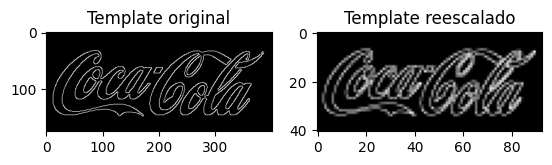

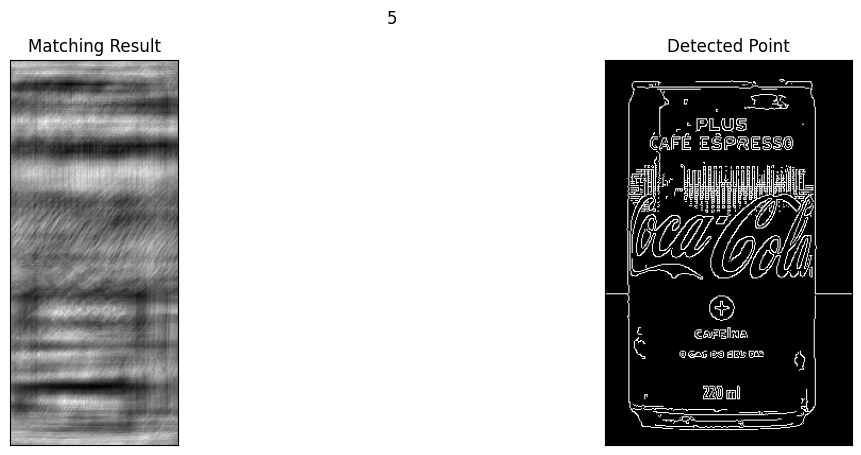

(363, 233)


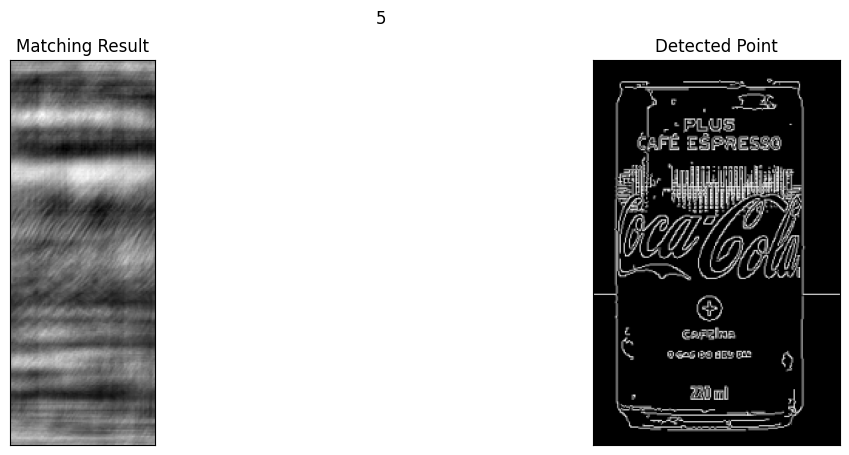

(290, 186)


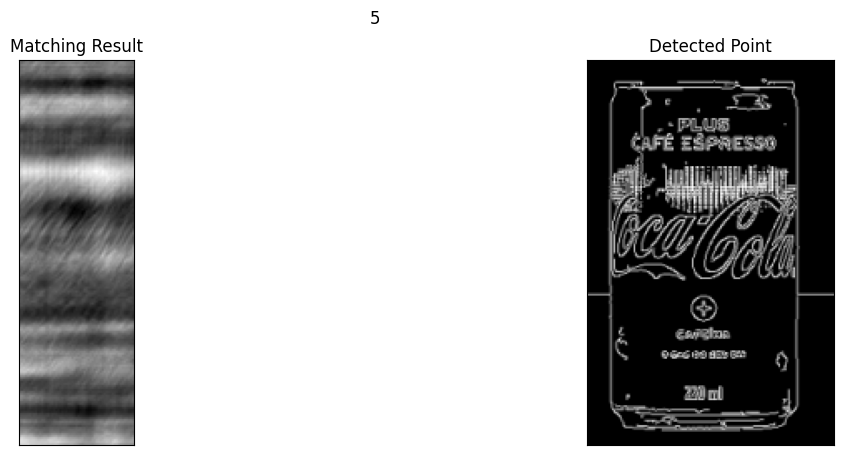

(232, 149)


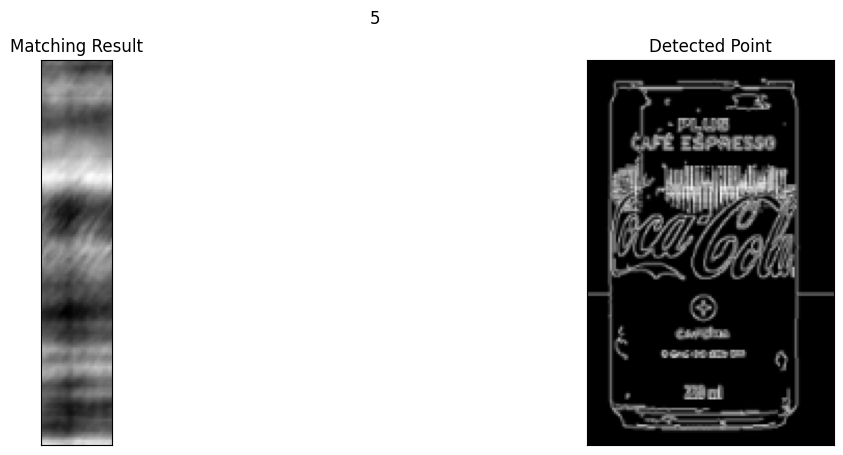

(186, 119)


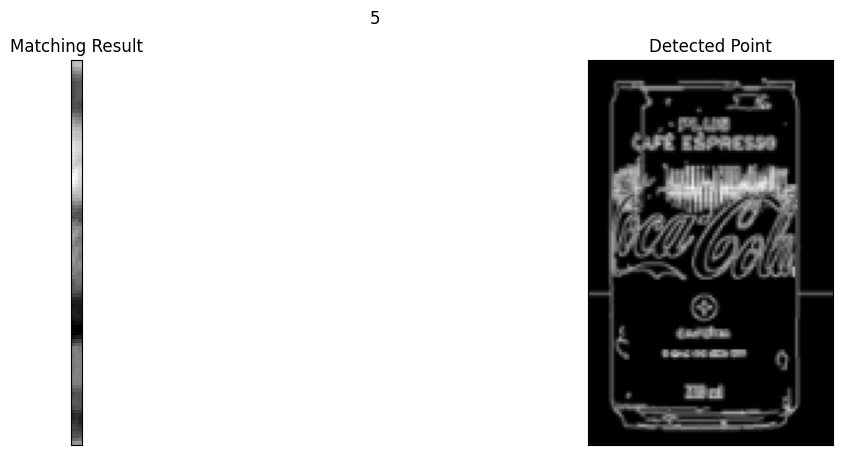

(149, 95)


In [6]:
detection_function(img_path="images/coca_logo_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

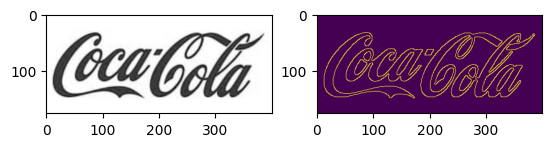

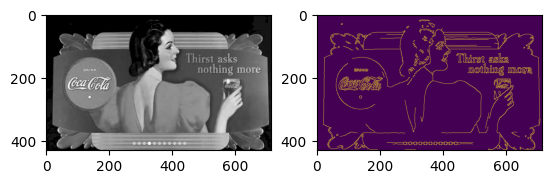

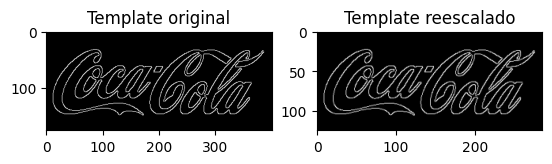

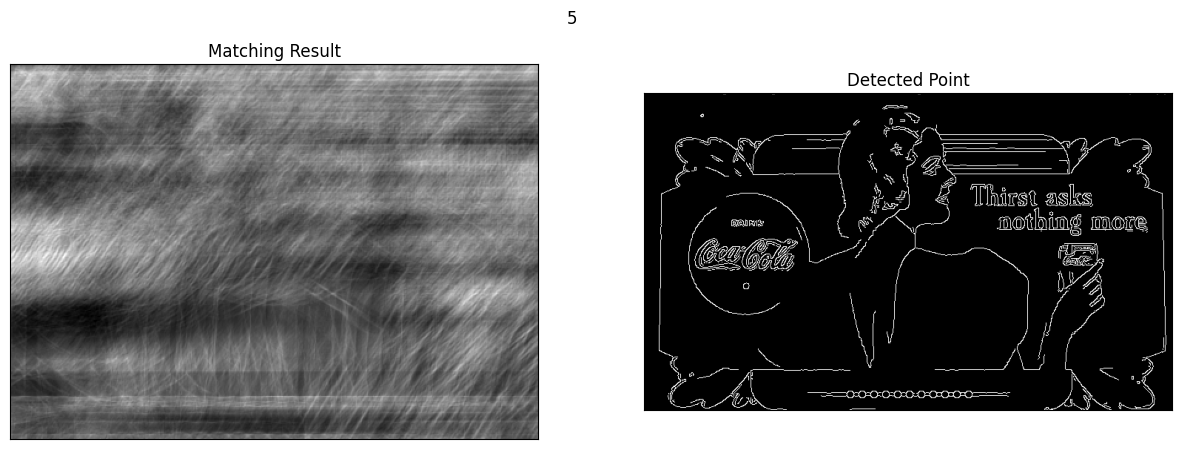

(429, 715)


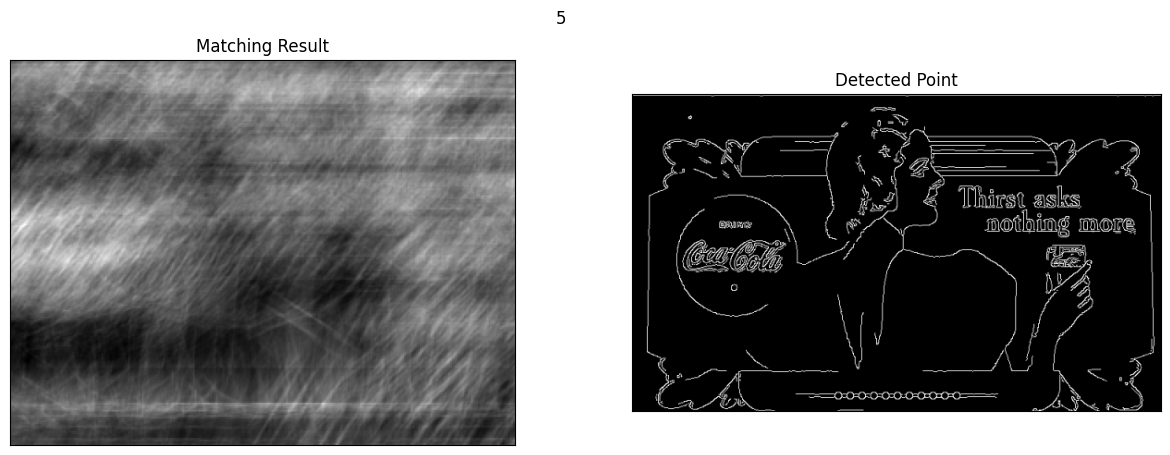

(343, 572)


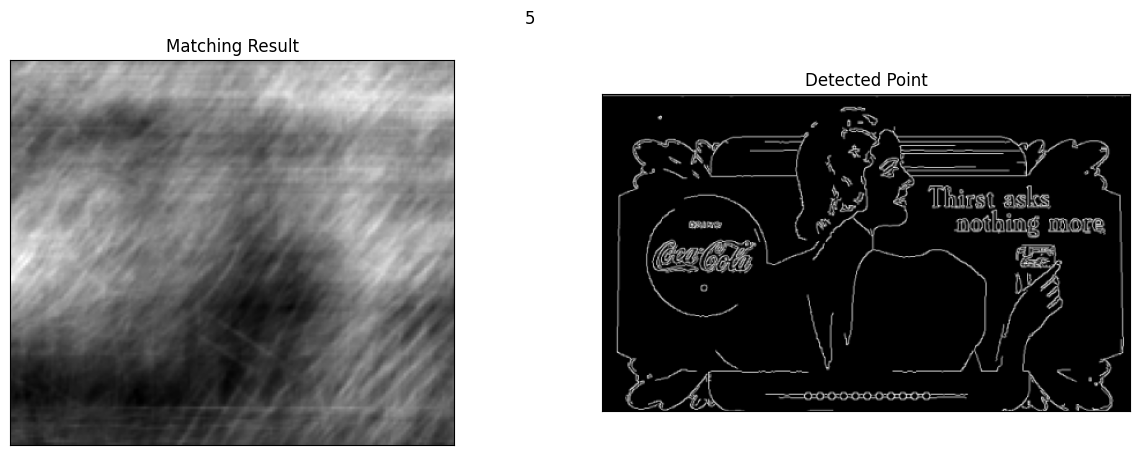

(274, 458)


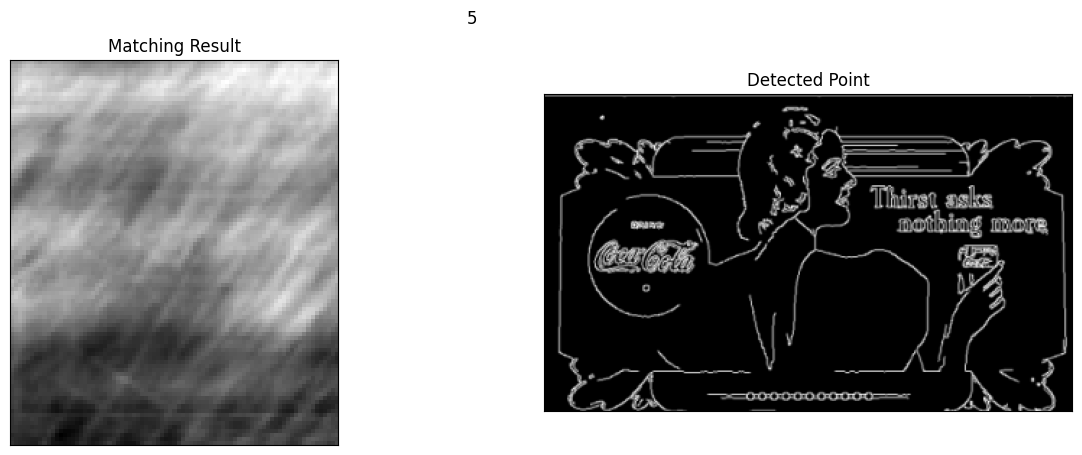

(219, 366)


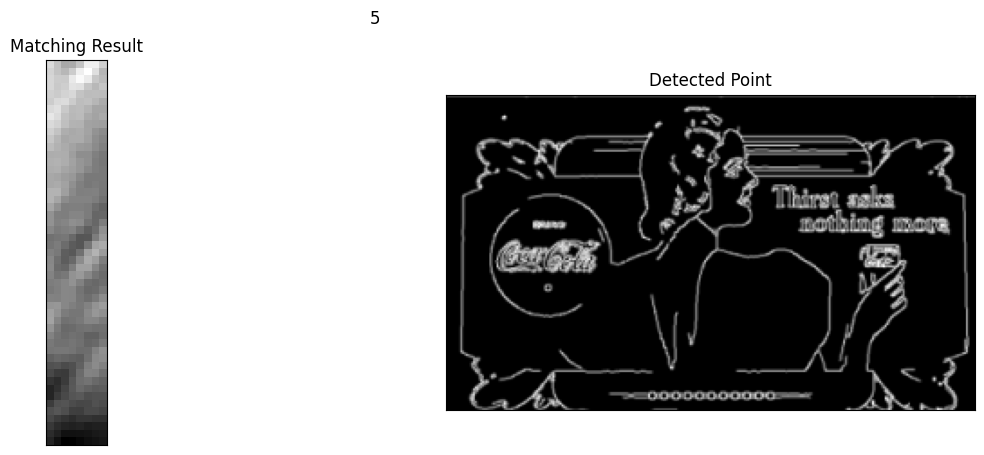

(175, 293)


In [7]:
detection_function(img_path="images/coca_retro_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

Analizando los resultados, encontramos que si bien, la logica parecía prometedora, esta era muy poco robusta, ante cambios en la imagen, los resultados variaban de manera notable, lo que lo hacía un metodo muy poco fiable. Ante cambios en la imagen, debíamos modificar los parámetros de escalado y threshhold, lo cual no era ideal para una aplicación real.

# Deteccion de features utilizando SIFT

Para probar una mejor versión de detección, se procedió utilizando el algoritmo SIFT. En principio, mejoró de forma notable la detección para algunas imagenes específicas, pero ; no corrigió completamente el problema. Se siguió utilizando la filosofía de aplicar canny para detectar bordes, asi no afectaba a la detección los tonos de grises variables del logo, o del fondo. A su vez, se decidió aplicar un filtro de sharpening (unsharp masking), con el objetivo de retirar el blur de algunas imagenes. Esto mejoró notablemente los resultados, logrando la detección de features en todas las imagenes. 

In [3]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline
%matplotlib inline
#%matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

Definimos funcion para realizar sharpening

In [2]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0):
    """
    Apply unsharp masking to sharpen an image.

    Parameters:
        image (numpy.ndarray): Input image to be sharpened.
        kernel_size (tuple): Size of the Gaussian kernel.
        sigma (float): Standard deviation for Gaussian kernel.
        amount (float): Strength of the sharpening effect.
        threshold (int): Minimum difference to apply sharpening.

    Returns:
        numpy.ndarray: Sharpened image.
    """
    # Apply Gaussian blur to the image
    blurred = cv.GaussianBlur(image, kernel_size, sigma)

    # Calculate the difference between the original and blurred image
    sharpened = float(amount) * (image - blurred) + image

    # Apply threshold to limit sharpening to significant differences
    if threshold > 0:
        low_contrast_mask = np.abs(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)

    # Clip the values to be in the valid range [0, 255] for uint8 images
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return sharpened

Función que realiza matcheo entre features de imagenes

In [3]:
def flann_match(kp1, kp2, des1, des2, img1, img2):

    # des1 = np.float32(des1)
    # des2 = np.float32(des2)
    FLANN_INDEX_KDTREE = 1
    #index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    #search_params = dict(checks = 2000000)
    #flann = cv.FlannBasedMatcher(index_params, search_params)
    matcher = cv.FlannBasedMatcher()
    matches = matcher.knnMatch(des1, des2, 2)
    #matches = flann.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < 0.80*n.distance:
            good.append(m)
    # print(len(good))

    indice_confianza = len(good) / len(matches)

    print(len(good))

    print(len(matches))

    MIN_MATCH_COUNT = 4


    #-- Localize the object
    obj = np.empty((len(good),2), dtype=np.float32)
    scene = np.empty((len(good),2), dtype=np.float32)
    for i in range(len(good)):
        #-- Get the keypoints from the good matches
        obj[i,0] = kp1[good[i].queryIdx].pt[0]
        obj[i,1] = kp1[good[i].queryIdx].pt[1]
        scene[i,0] = kp2[good[i].trainIdx].pt[0]
        scene[i,1] = kp2[good[i].trainIdx].pt[1]
    
    
    if len(good) >= MIN_MATCH_COUNT:
        #src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        #dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        #M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        M,mask =  cv.findHomography(obj, scene, cv.RANSAC)
        matchesMask = mask.ravel().tolist()
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h],[w,h],[w,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img3 = cv.polylines(img2, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
        # print(mask)

        #-- Get the corners from the image_1 ( the object to be "detected" )
        obj_corners = np.empty((4,1,2), dtype=np.float32)
        obj_corners[0,0,0] = 0
        obj_corners[0,0,1] = 0
        obj_corners[1,0,0] = img2.shape[1]
        obj_corners[1,0,1] = 0
        obj_corners[2,0,0] = img2.shape[1]
        obj_corners[2,0,1] = img2.shape[0]
        obj_corners[3,0,0] = 0
        obj_corners[3,0,1] = img2.shape[0]
 
        scene_corners = cv.perspectiveTransform(obj_corners, M)
        

        return good, matchesMask, img3, indice_confianza, scene_corners
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(len(good), MIN_MATCH_COUNT) )
        matchesMask = None

Para agilizar el proceso, se desarrolló esta función, que permite iterar rapidamente los principales parámetros a validar

In [48]:
def ejecucion_general(kernel_size, sigma, amount, threshold, cannny_1, canny_2):
    # Cargamos la imagen a buscar
    template = cv.imread('template/pattern.png')
    template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
    template_edges = cv.Canny(template, threshold1=5, threshold2=200)

    images = []
    images_edges = []
    for filename in os.listdir('images'):
        img = cv.imread(os.path.join('images', filename))
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = unsharp_mask(img, kernel_size=kernel_size, sigma=sigma, amount=amount, threshold=threshold)
        
        img_edges = cv.Canny(img, threshold1=cannny_1, threshold2=canny_2)

        images.append(img)
        images_edges.append(img_edges)

    
    plt.figure(figsize=(15, 10))

    # Plot the first image
    plt.subplot(1, 2, 1)
    plt.imshow(images[0], cmap='gray')
    plt.title('First Image')
    plt.axis('off')

    # Plot the edges of the first image
    plt.subplot(1, 2, 2)
    plt.imshow(images_edges[0], cmap='gray')
    plt.title('Edges of First Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Creamos el vector de características SIFT
    sift = cv.SIFT_create(nfeatures=10000, contrastThreshold=0.0001, edgeThreshold=0.0001)

    # Y buscamos según el algoritmo...
    kp, des = sift.detectAndCompute(template_edges, None)

    images_kp_des = {}

    for i, img in enumerate(images_edges):
        kp_i, des_i = sift.detectAndCompute(img, None)
        images_kp_des[i] = (kp_i, des_i)

    print(len(kp))
    print(len(images_kp_des[0][0]))

    matches = {}
    for i, (kp_i, des_i) in images_kp_des.items():
        try:
            good, mask, img_matches, indice_confianza, scene_corner = flann_match(kp, kp_i, des, des_i, template_edges, images_edges[i])
            matches[i] = (good, mask, img_matches, indice_confianza, scene_corner)
        except Exception as e:
            print(f"Error processing image {i}: {e}")

    """    for i, (good, mask, img_matches, indice_confianza, scene_corner) in matches.items():
        draw_params = dict(matchColor = (0,255,0), # dibujar coincidencias en verde
                        singlePointColor = None,
                        matchesMask = mask, # dibujar solo inliers
                        flags = 2)
        img_4 = cv.drawMatches(template, kp, images[i], images_kp_des[i][0], good, None, **draw_params)
        plt.imshow(img_4, 'gray')
        plt.title(f'Matches for image {i}')
        plt.axis('off')
        plt.show()"""
    for i, (good, mask, img_matches, indice_confianza, scene_corners) in matches.items():
        # 1. Mostrar matches con líneas
        draw_params = dict(matchColor = (0,255,0),
                        singlePointColor = None,
                        matchesMask = mask,
                        flags = 2)
        img_4 = cv.drawMatches(template, kp, images[i], images_kp_des[i][0], good, None, **draw_params)
        plt.imshow(img_4, 'gray')
        plt.title(f'Matches for image {i}')
        plt.axis('off')
        plt.show()

        # 2. Dibujar el boundary box sobre la imagen original
        img_with_box = images[i].copy()


        
        # Asegurarse de que las coordenadas estén en el formato correcto
        corners = scene_corners.reshape(-1, 2).astype(int)

        # Dibujar líneas entre las esquinas
        cv.line(img_with_box, tuple(corners[0]), tuple(corners[1]), (0, 255, 0), 4)
        cv.line(img_with_box, tuple(corners[1]), tuple(corners[2]), (0, 255, 0), 4)
        cv.line(img_with_box, tuple(corners[2]), tuple(corners[3]), (0, 255, 0), 4)
        cv.line(img_with_box, tuple(corners[3]), tuple(corners[0]), (0, 255, 0), 4)

        # Dibujar el índice de confianza (en la esquina superior izquierda del bounding box)
        conf_text = f"{indice_confianza:.2f}"
        cv.putText(img_with_box, conf_text, tuple(corners[0]), cv.FONT_HERSHEY_SIMPLEX, 
                1.0, (0, 0, 255), 2, cv.LINE_AA)


        #-- Draw lines between the corners (the mapped object in the scene - image_2 )
        cv.line(img_with_box, (int(scene_corners[0,0,0] + template.shape[1]), int(scene_corners[0,0,1])),\
            (int(scene_corners[1,0,0] + template.shape[1]), int(scene_corners[1,0,1])), (0,255,0), 4)
        cv.line(img_with_box, (int(scene_corners[1,0,0] + template.shape[1]), int(scene_corners[1,0,1])),\
            (int(scene_corners[2,0,0] + template.shape[1]), int(scene_corners[2,0,1])), (0,255,0), 4)
        cv.line(img_with_box, (int(scene_corners[2,0,0] + template.shape[1]), int(scene_corners[2,0,1])),\
            (int(scene_corners[3,0,0] + template.shape[1]), int(scene_corners[3,0,1])), (0,255,0), 4)
        cv.line(img_with_box, (int(scene_corners[3,0,0] + template.shape[1]), int(scene_corners[3,0,1])),\
            (int(scene_corners[0,0,0] + template.shape[1]), int(scene_corners[0,0,1])), (0,255,0), 4)
        
        # Mostrar la imagen con bounding box
        plt.imshow(cv.cvtColor(img_with_box, cv.COLOR_BGR2RGB))
        plt.title(f'Bounding Box for image {i}')
        plt.axis('off')
        plt.show()

In [288]:
def funcion_copada(img_name):

    kernel_size=(3, 3)
    sigma=0.5
    amount=0.13
    threshold=0
    cannny_1 = 150
    canny_2= 350
    lowes_ratio = 0.80

    template = cv.imread('template/pattern.png')
    template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
    img_object = cv.Canny(template, threshold1=5, threshold2=200)



    img = cv.imread(os.path.join('images', img_name), cv.IMREAD_GRAYSCALE)
    img_scene = img.copy()
    img_scene = unsharp_mask(img_scene, kernel_size=kernel_size, sigma=sigma, amount=amount, threshold=threshold)
    
    img_scene = cv.Canny(img_scene, threshold1=cannny_1, threshold2=canny_2)

    
    if img_object is None or img_scene is None:
        print('Could not open or find the images!')
        exit(0)
    
    #-- Step 1: Detect the keypoints using SURF Detector, compute the descriptors

    # Creamos el vector de características SIFT
    sift = cv.SIFT_create()

    # Y buscamos según el algoritmo...
    keypoints_obj, descriptors_obj = sift.detectAndCompute(img_object, None)

    keypoints_scene, descriptors_scene = sift.detectAndCompute(img_scene, None)

    
    #-- Step 2: Matching descriptor vectors with a FLANN based matcher
    matcher = cv.DescriptorMatcher_create(cv.DescriptorMatcher_FLANNBASED)
    knn_matches = matcher.knnMatch(descriptors_obj, descriptors_scene, 2)
    
    #-- Filter matches using the Lowe's ratio test
    ratio_thresh = lowes_ratio
    good_matches = []
    for m,n in knn_matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
    
    #-- Draw matches
    img_matches = np.empty((max(img_object.shape[0], img_scene.shape[0]), img_object.shape[1]+img_scene.shape[1], 3), dtype=np.uint8)
    cv.drawMatches(img_object, keypoints_obj, img_scene, keypoints_scene, good_matches, img_matches, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    #-- Localize the object
    obj = np.empty((len(good_matches),2), dtype=np.float32)
    scene = np.empty((len(good_matches),2), dtype=np.float32)
    for i in range(len(good_matches)):
        #-- Get the keypoints from the good matches
        obj[i,0] = keypoints_obj[good_matches[i].queryIdx].pt[0]
        obj[i,1] = keypoints_obj[good_matches[i].queryIdx].pt[1]
        scene[i,0] = keypoints_scene[good_matches[i].trainIdx].pt[0]
        scene[i,1] = keypoints_scene[good_matches[i].trainIdx].pt[1]
    
    H, _ =  cv.findHomography(obj, scene, cv.RANSAC)
    
    #-- Get the corners from the image_1 ( the object to be "detected" )
    obj_corners = np.empty((4,1,2), dtype=np.float32)
    obj_corners[0,0,0] = 0
    obj_corners[0,0,1] = 0
    obj_corners[1,0,0] = img_object.shape[1]
    obj_corners[1,0,1] = 0
    obj_corners[2,0,0] = img_object.shape[1]
    obj_corners[2,0,1] = img_object.shape[0]
    obj_corners[3,0,0] = 0
    obj_corners[3,0,1] = img_object.shape[0]
    
    scene_corners = cv.perspectiveTransform(obj_corners, H)
    
    #-- Draw lines between the corners (the mapped object in the scene - image_2 )
    cv.line(img_matches, (int(scene_corners[0,0,0] + img_object.shape[1]), int(scene_corners[0,0,1])),\
        (int(scene_corners[1,0,0] + img_object.shape[1]), int(scene_corners[1,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[1,0,0] + img_object.shape[1]), int(scene_corners[1,0,1])),\
        (int(scene_corners[2,0,0] + img_object.shape[1]), int(scene_corners[2,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[2,0,0] + img_object.shape[1]), int(scene_corners[2,0,1])),\
        (int(scene_corners[3,0,0] + img_object.shape[1]), int(scene_corners[3,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[3,0,0] + img_object.shape[1]), int(scene_corners[3,0,1])),\
        (int(scene_corners[0,0,0] + img_object.shape[1]), int(scene_corners[0,0,1])), (0,255,0), 4)
    

    plt.figure(figsize=(15, 10))
    plt.imshow(cv.cvtColor(img_matches, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

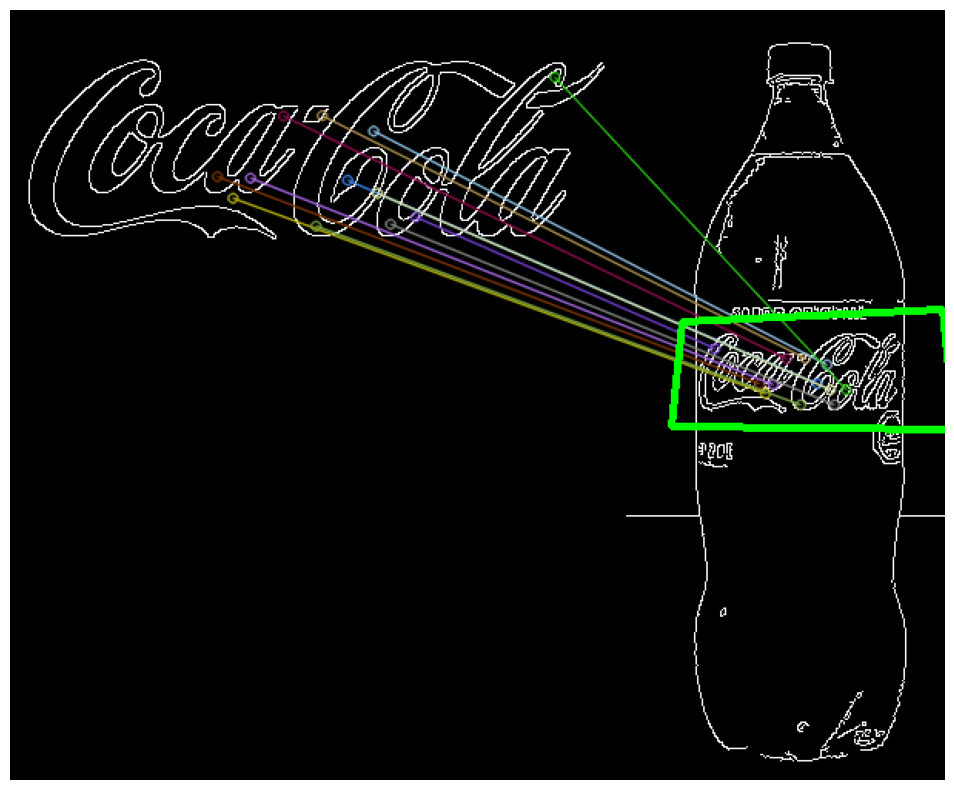

In [289]:
funcion_copada(img_name="coca_logo_1.png")

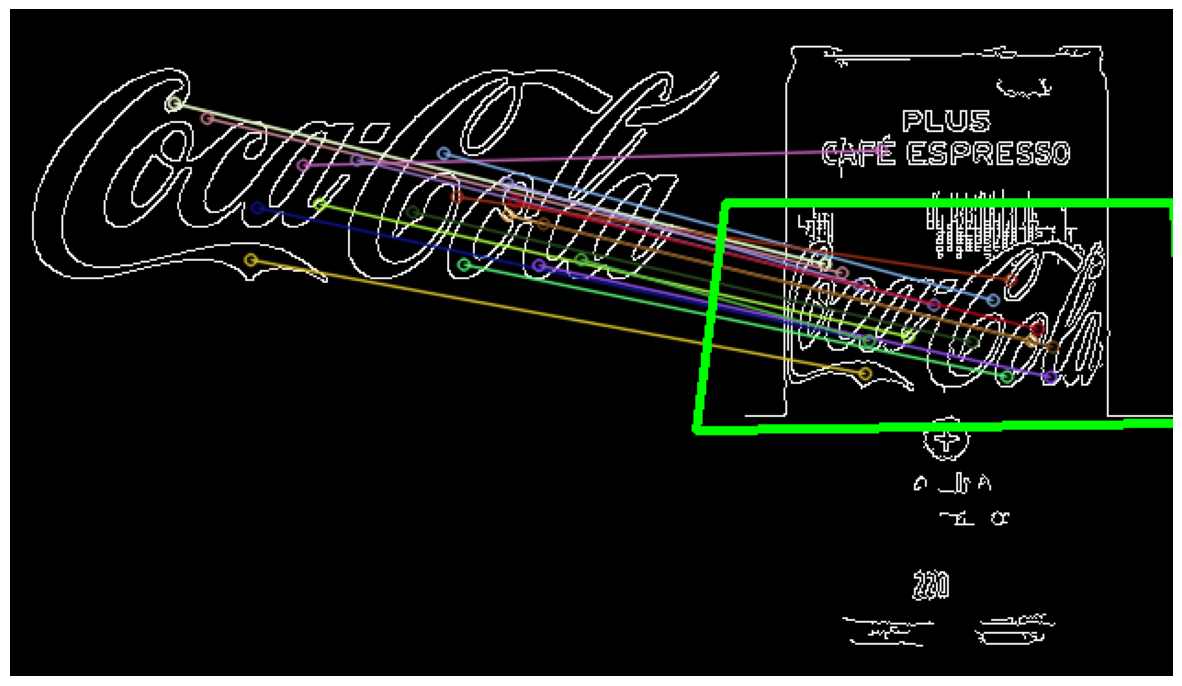

In [250]:
funcion_copada(img_name="coca_logo_2.png")

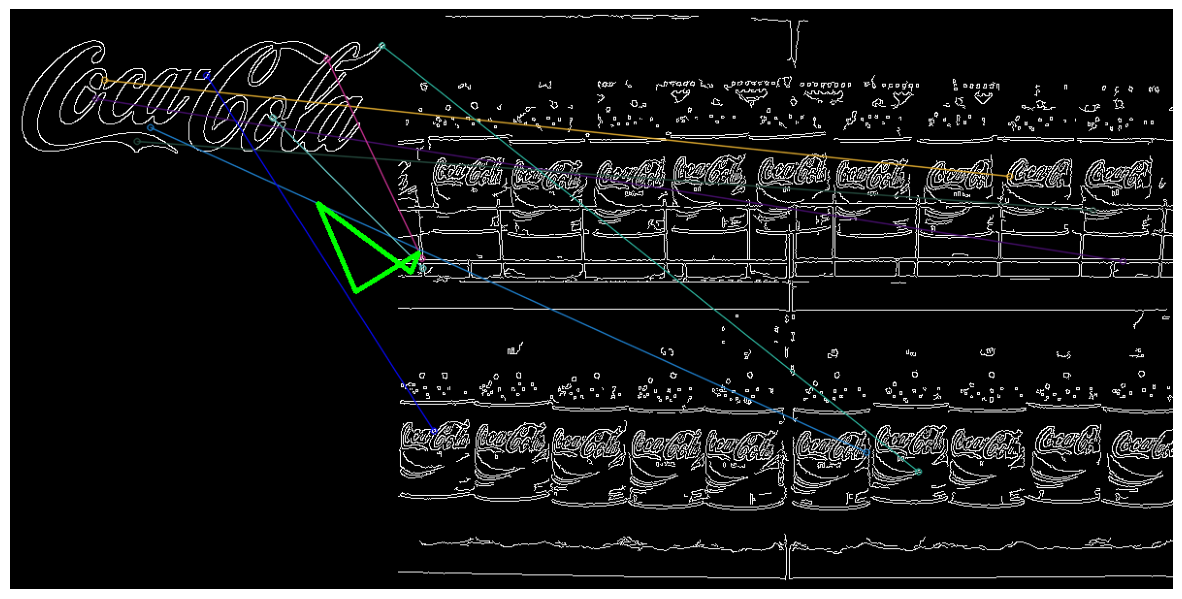

In [291]:
funcion_copada(img_name="coca_multi.png")

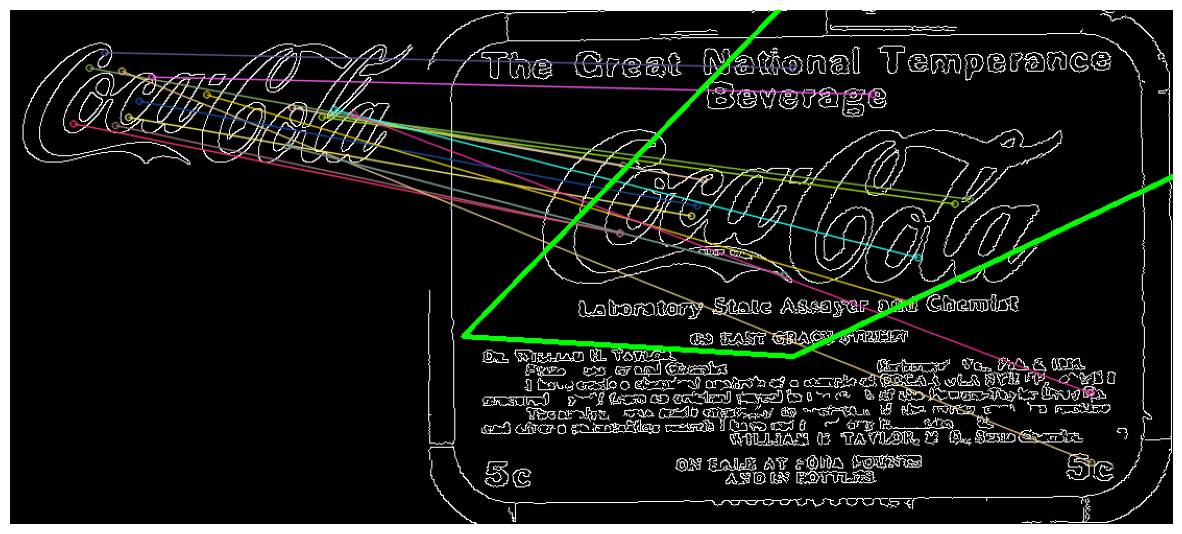

In [292]:
funcion_copada(img_name="coca_retro_1.png")

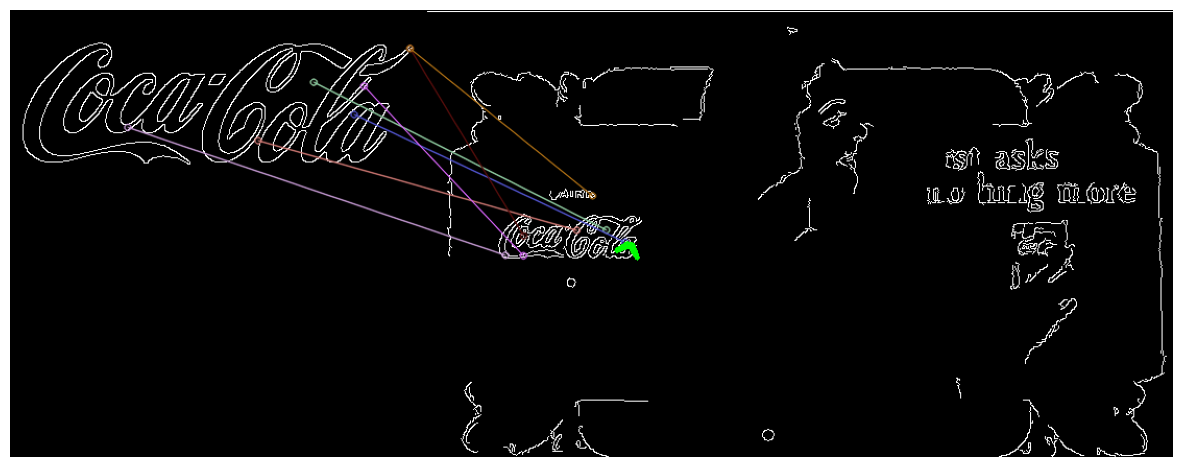

In [280]:
funcion_copada(img_name="coca_retro_2.png")

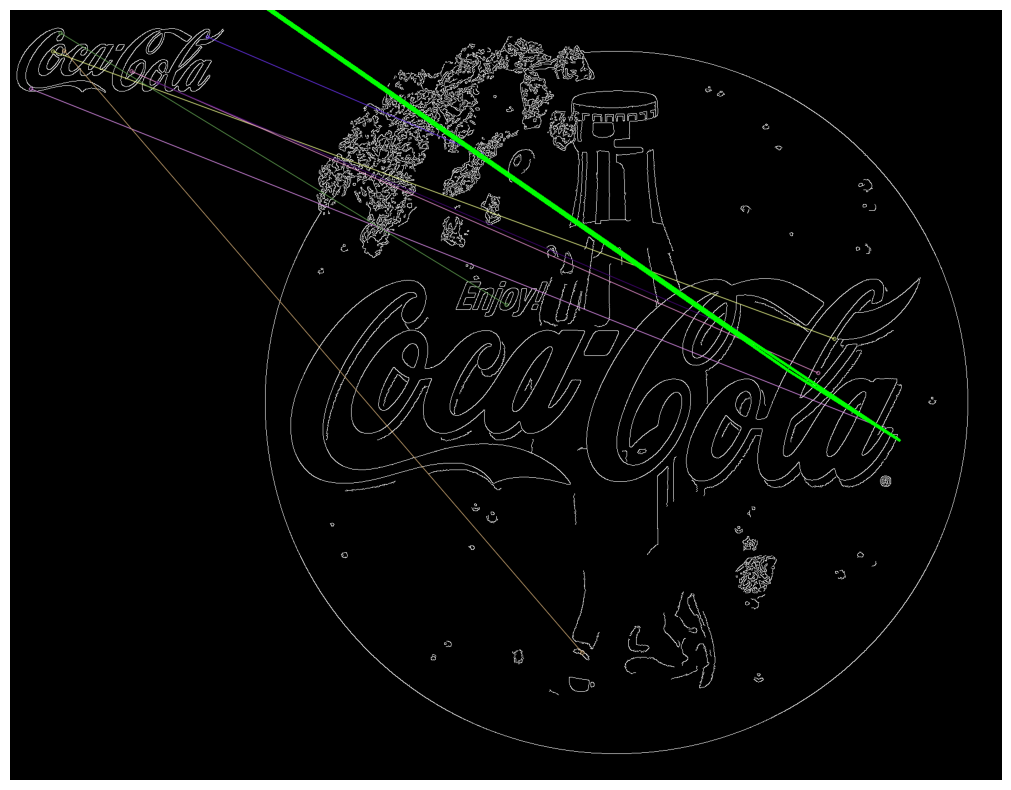

In [293]:
funcion_copada(img_name="COCA-COLA-LOGO.jpg")

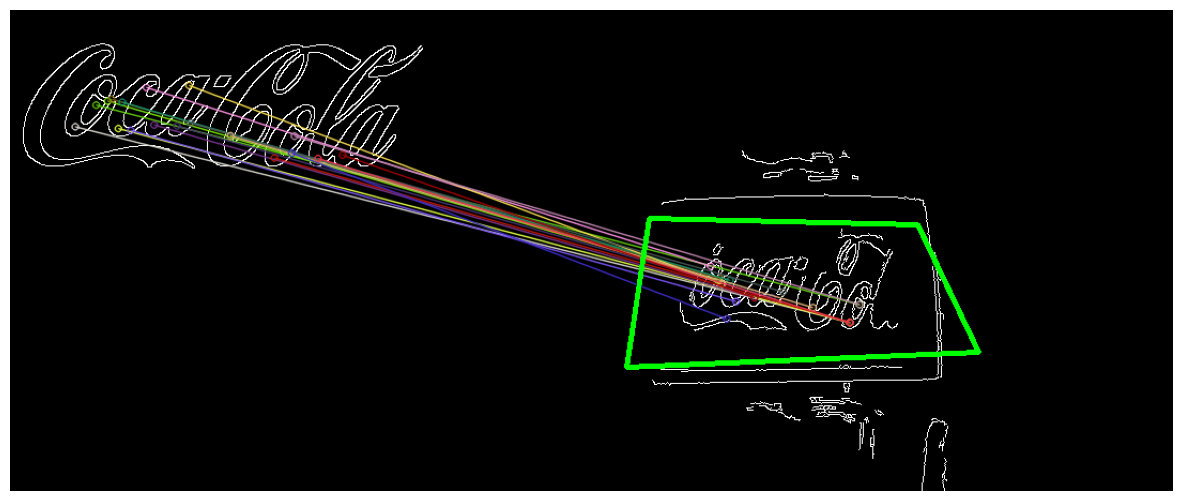

In [294]:
funcion_copada(img_name="logo_1.png")

Ejecución de la función

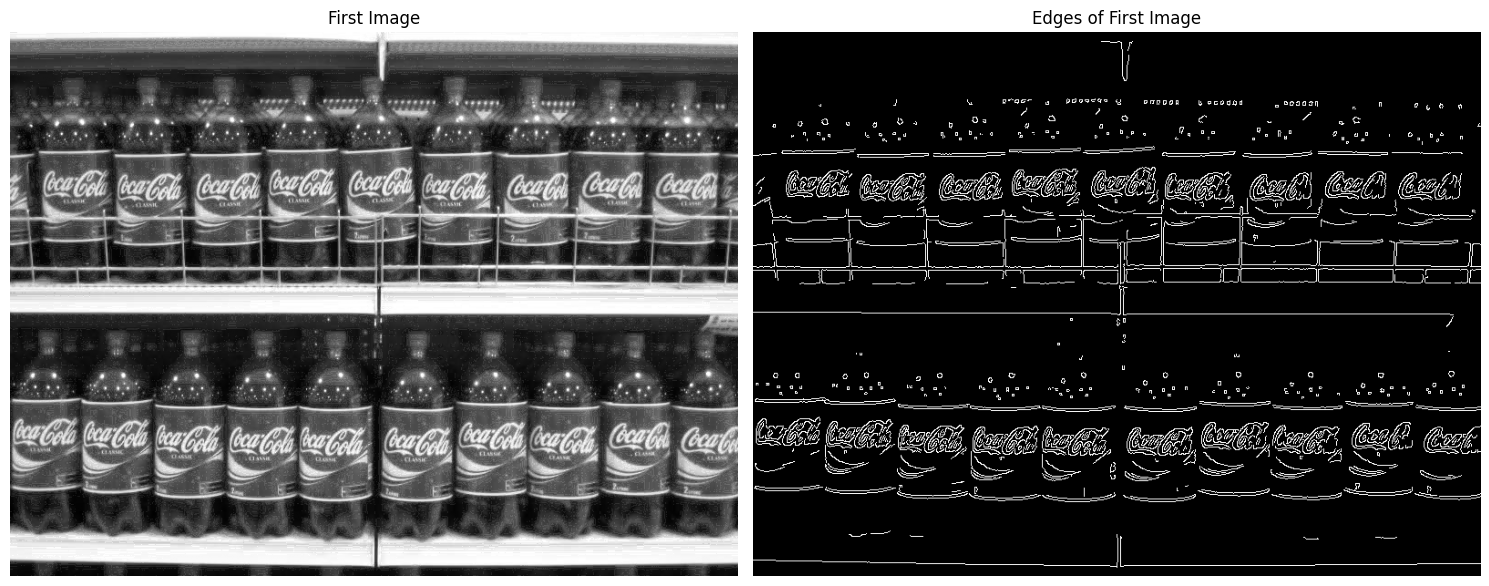

234
2047
2
234
No se encontraron suficientes coincidencias - 2/4
Error processing image 0: cannot unpack non-iterable NoneType object
31
234
78
234
30
234
24
234
40
234
22
234


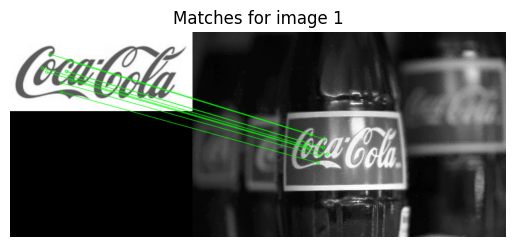

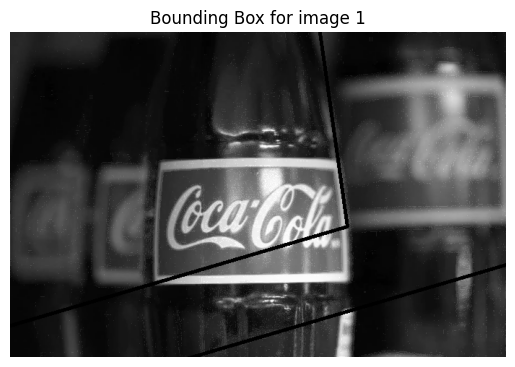

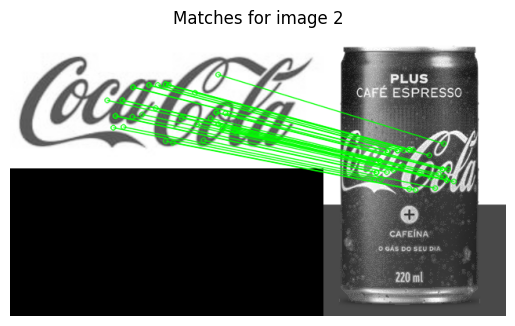

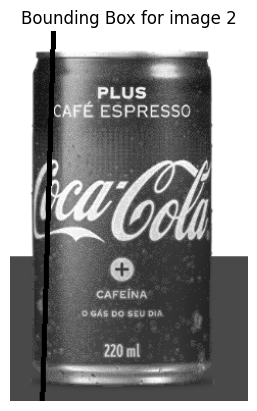

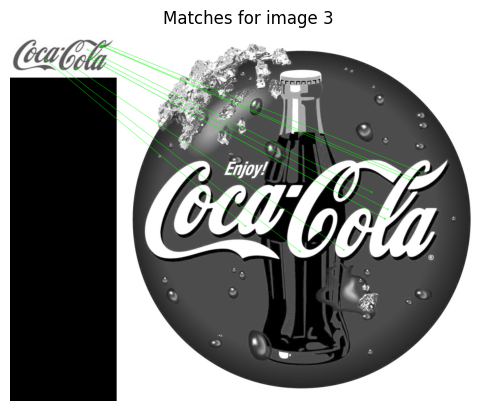

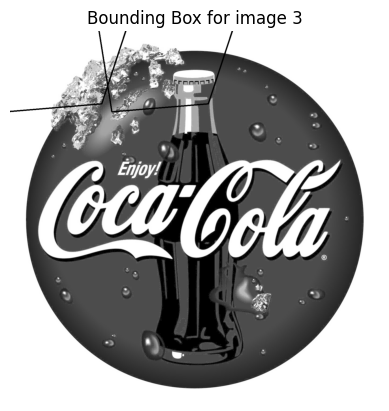

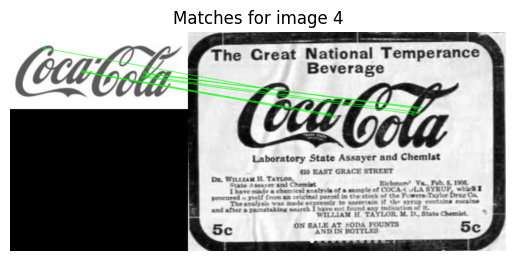

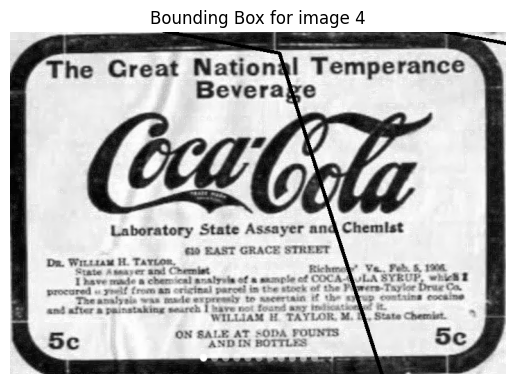

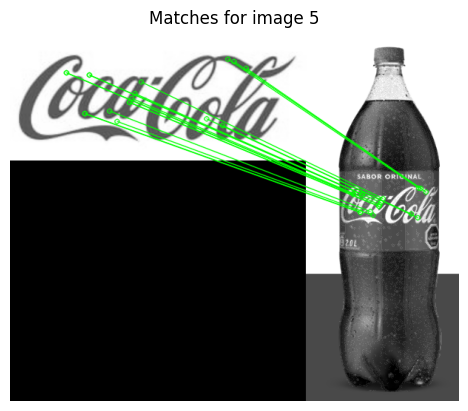

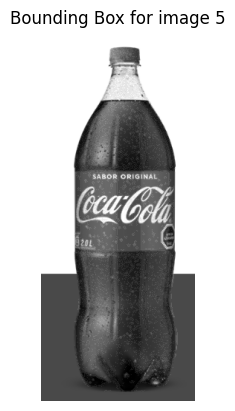

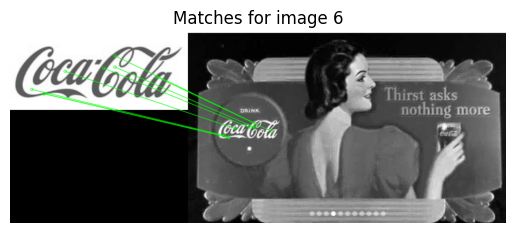

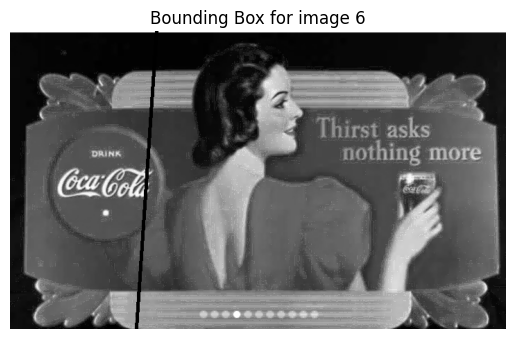

In [49]:
ejecucion_general(kernel_size=(7, 7), sigma=0.5, amount=0.1, threshold=0, cannny_1 = 300, canny_2= 500)

Podemos ver así como la utilización conjunta de sift y canny, con filtros aplicados para mejorar la imagen inicial produjeron mejores resultados a que el algoritmo desarrollado inicialmente. 